<a href="https://colab.research.google.com/github/NTejasri-2520030139/ML-Project-/blob/main/project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATASET OVERVIEW ===
Total Records (Rows): 1500
Total Columns: 9

=== COLUMN DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB
None

=== SUMMARY STATISTICS ===
               Age       Gender   AnnualIncome  NumberOfPurchases  \
count  1500.000000  1500.000000    1500.000000        1500.000000   
mean     44.298667 

/tmp/ipykernel_1997/3724852411.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette="viridis")


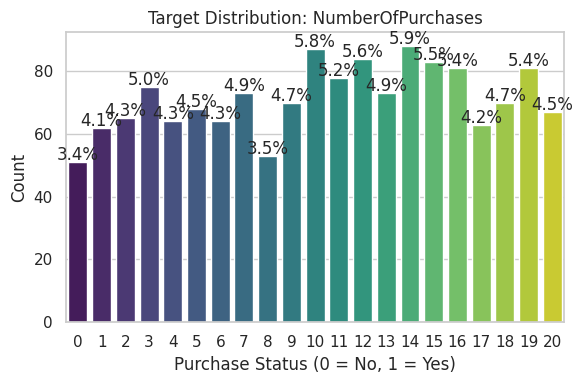

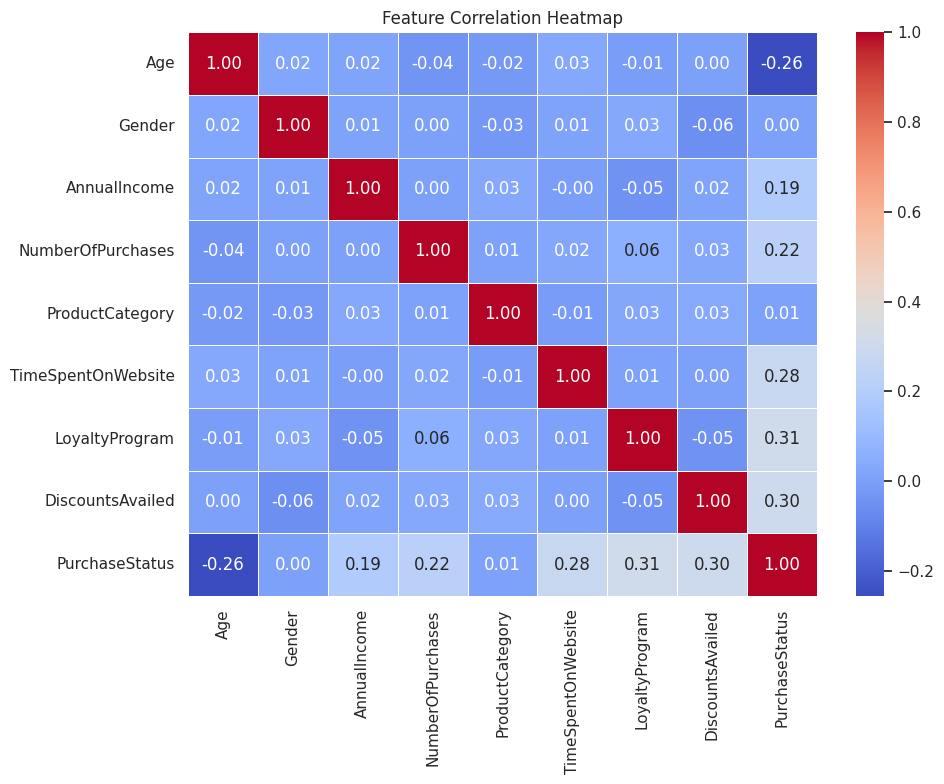

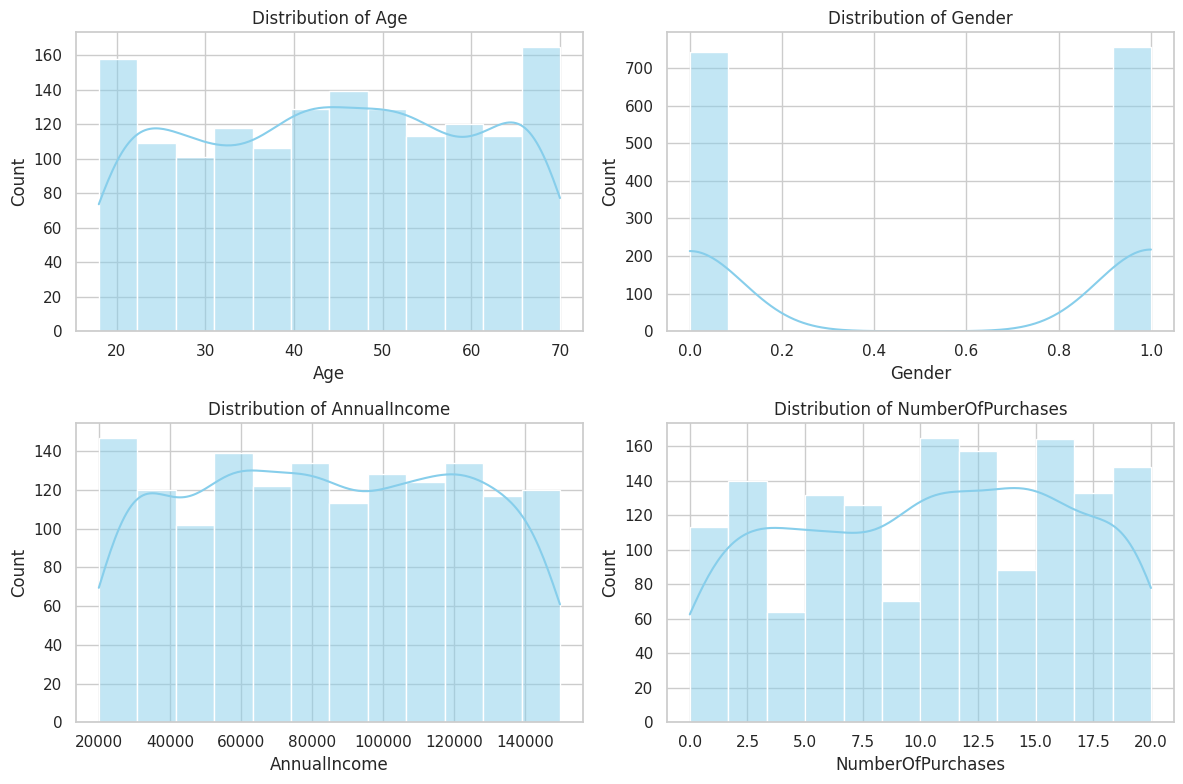

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load CSV file
df = pd.read_csv("e_commerce_user_data.csv.zip")

# ==========================================
# 1. DISPLAY DATASET SUMMARY METRICS
# ==========================================
print("=== DATASET OVERVIEW ===")
print(f"Total Records (Rows): {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\n=== COLUMN DATA TYPES & MISSING VALUES ===")
print(df.info())

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

# ==========================================
# 2. GRAPH 1: TARGET CLASS DISTRIBUTION
# ==========================================
# Identifies class balance for purchase decisions
target_col = [col for col in df.columns if 'purchase' in col.lower() or 'label' in col.lower() or 'target' in col.lower()][0]

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target_col, data=df, palette="viridis")
plt.title(f"Target Distribution: {target_col}")
plt.xlabel("Purchase Status (0 = No, 1 = Yes)")
plt.ylabel("Count")

# Add percentage labels to bars
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# ==========================================
# 3. GRAPH 2: FEATURE CORRELATION HEATMAP
# ==========================================
# Shows relationships between numeric features and purchase decisions
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================
# 4. GRAPH 3: NUMERIC FEATURE DISTRIBUTIONS
# ==========================================
# Histograms for key numerical behavior indicators
num_cols = numeric_df.columns[:4]  # Plot top 4 numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, col in enumerate(num_cols):
    row, c = divmod(idx, 2)
    sns.histplot(df[col], kde=True, ax=axes[row, c], color="skyblue")
    axes[row, c].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()